In [3]:
import pandas as pd
import os.path as op
import numpy as np
from os import listdir

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
bids_folder_behav ='/Users/mrenke/data/ds-stressrisk'
subFolders = [f for f in listdir(bids_folder) if f[0:3] == 'sub']

decod_dir = op.join(bids_folder, 'derivatives', 'decoded_pdfs.volume.svoxels.ses1-en_ses2-de.denoise.retroicor' )
sub='01'



In [4]:
from stress_risk.utils.data import get_data

df = get_data(bids_folder = bids_folder_behav)
df = df[df['session'] == 2]

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import os
import re

def get_decod(subject, decod_dir):
    #mask='NPC_R'

    fils = os.listdir(op.join(decod_dir,f'{subject}','func'))
    for f in fils:
        if re.match(f'{subject}_ses1-en_ses2-de', f):
            file = f

    #subject = f'{sub:02d}'
    pdf = op.join(decod_dir,f'{subject}','func', file)
    pdf = pd.read_csv(pdf, sep='\t', index_col=[0])
    pdf = pdf.set_index('trial_nr')
    pdf.columns = pdf.columns.astype(float)
    pdf = pdf.loc[:, np.log(5):np.log(28*4)]

    E = (pdf*pdf.columns.values[np.newaxis, :] / pdf.sum(1).values[:, np.newaxis]).sum(1)
    E = pd.DataFrame(E)
    E = E.rename(columns={0:'E'})
    pdf /= np.trapz(pdf, pdf.columns.astype(float))[:, np.newaxis] #normalizing

    E['sd'] = np.trapz(np.abs(E.values - pdf.columns.astype(float).values[np.newaxis, :]) * pdf, pdf.columns, axis=1)
    E['subject'] = int(subject[4:])
    E = E.reset_index().set_index(['subject','trial_nr'])
    
    return E


In [6]:
subject = subFolders[1]

fils = os.listdir(op.join(decod_dir,f'{subject}','func'))
for f in fils:
    if re.match(f'{subject}_ses1-en_ses2-de', f):
        file = f

#subject = f'{sub:02d}'
pdf = op.join(decod_dir,f'{subject}','func', file)
pdf = pd.read_csv(pdf, sep='\t', index_col=[0])
pdf = pdf.set_index('trial_nr')
pdf.columns = pdf.columns.astype(float)

In [4]:
#Es = [get_decod(subject, decod_dir) for subject in subFolders]

Es = pd.DataFrame()

for subject in subFolders:
    try:
        E = get_decod(subject, decod_dir)
        Es = pd.concat([Es, E])
    except:
        print(f'{subject} makes problems')


In [6]:
temp = Es.join(df.reset_index().set_index(['subject','trial_nr'])[['n1', 'group']])
temp['log_n1'] = np.log(temp['n1'])


In [7]:
import pingouin

r = temp.groupby(['subject']).apply(lambda d: pingouin.corr(d['E'], d['log_n1']))

from stress_risk.utils.data import add_cond2df
r = add_cond2df(r)

In [1]:
import seaborn as sns

mean_E = temp.groupby(['subject', 'group'])[['E']].mean()
sns.catplot(data=mean_E.reset_index(), x='group', y='E',kind='point')

pingouin.anova(data=temp.groupby('subject'),dv='E', between='group')


NameError: name 'temp' is not defined

,Source,ddof1,ddof2,F,p-unc,np2
0,group,1,48,1.388744,0.244426,0.028119


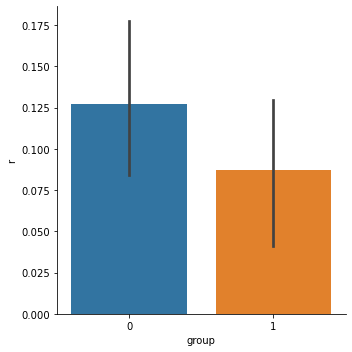

In [10]:
import seaborn as sns

sns.catplot(data=r, x='group', y='r', kind='bar')
pingouin.anova(data=r,dv='r', between='group')


<AxesSubplot: xlabel='log_n1', ylabel='E'>

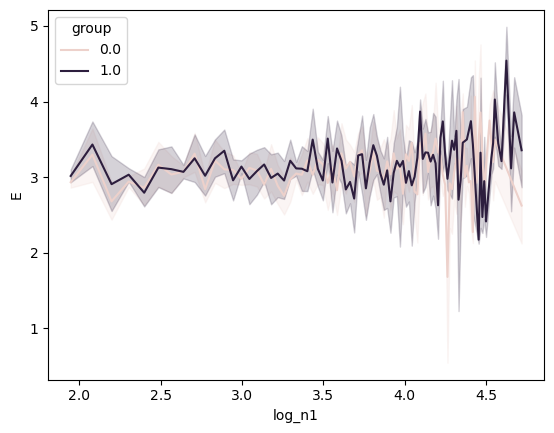

In [82]:
import seaborn as sns
sns.lineplot(temp, x='log_n1', y='E', hue='group')

In [ ]:
sns.catplot(x='group', y='r', data=r...)

In [1]:
import pingouin

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
# r = ...


# sns.catplot(x='group', y='r', data=r...)



pingouin.anova(dv='r', )

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1840131338.py, line 4)

In [3]:
import bambi

ModuleNotFoundError: No module named 'bambi'

In [ ]:
sns.lineplot(x='log_n', y='E', hue='group')

In [ ]:
model = bambi.Model('E ~ log_n*group')

